# IBM AML Small 데이터셋 EDA — GNN 모델링 관점

**HI-Small vs LI-Small 비교 + 그래프 구조 심층 분석**

- 작성: taehoon (팀 프로젝트 `money_laundry`)
- 원천 데이터: `C:/Users/aica_/Documents/kimi/workspace/AML/` (읽기 전용)
  - `HI-Small_Trans.csv` / `HI-Small_accounts.csv` / `HI-Small_Patterns.txt`
  - `LI-Small_Trans.csv` / `LI-Small_accounts.csv` / `LI-Small_Patterns.txt`
- 선행 분석(`docs/02_data/donghyeon/eda_small.ipynb`)이 기본 통계와 분포 비교를 다루므로,
  본 노트북은 기본 EDA를 포괄하면서 **GNN 모델링 관점의 그래프 구조 분석**
  (차수 분포, Fan-in/Fan-out, 연결요소, 노드 피처 후보)을 심층적으로 다루는 것이 차별점이다.
- HI = High Income(고소득 국가 중심), LI = Low Income(저소득 국가 중심) 시뮬레이션으로,
  두 데이터셋은 독립 시뮬레이션이므로 계좌 ID 체계가 서로 다르다(절대 병합하지 않고 분포만 비교).

## 1. 환경 설정 및 데이터 로드

- Trans CSV의 컬럼명 `Account`가 From/To 두 번 중복되므로 로드 시 `FromAccount`/`ToAccount`로 변경한다.
- 대용량(수백 MB)이므로 우선 `str`로 읽은 뒤 필요한 컬럼만 수치/시간/범주형으로 변환한다.

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'  # set_style 이후에 지정해야 덮어쓰이지 않음
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

DATA_DIR = r'C:/Users/aica_/Documents/kimi/workspace/AML'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=120, bbox_inches='tight')

# 분석 중 수집한 핵심 수치를 담아 마지막 요약에서 출력
summary = {}
print('환경 설정 완료')

환경 설정 완료


In [2]:
TRANS_COLS = ['Timestamp', 'FromBank', 'FromAccount', 'ToBank', 'ToAccount',
              'AmountReceived', 'ReceivingCurrency', 'AmountPaid',
              'PaymentCurrency', 'PaymentFormat', 'IsLaundering']

def load_trans(path):
    df = pd.read_csv(path, dtype=str)
    df.columns = TRANS_COLS  # 중복 컬럼명 Account -> FromAccount/ToAccount
    df['AmountReceived'] = pd.to_numeric(df['AmountReceived'])
    df['AmountPaid'] = pd.to_numeric(df['AmountPaid'])
    df['IsLaundering'] = df['IsLaundering'].astype(np.int8)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M')
    for c in ['ReceivingCurrency', 'PaymentCurrency', 'PaymentFormat']:
        df[c] = df[c].astype('category')
    return df

hi = load_trans(os.path.join(DATA_DIR, 'HI-Small_Trans.csv'))
li = load_trans(os.path.join(DATA_DIR, 'LI-Small_Trans.csv'))
hi_acc = pd.read_csv(os.path.join(DATA_DIR, 'HI-Small_accounts.csv'), dtype=str)
li_acc = pd.read_csv(os.path.join(DATA_DIR, 'LI-Small_accounts.csv'), dtype=str)

print(f'HI-Small Trans: {hi.shape}, Accounts: {hi_acc.shape}')
print(f'LI-Small Trans: {li.shape}, Accounts: {li_acc.shape}')

HI-Small Trans: (5078345, 11), Accounts: (518581, 5)
LI-Small Trans: (6924049, 11), Accounts: (712688, 5)


In [3]:
hi.head(3)

,Timestamp,FromBank,FromAccount,ToBank,ToAccount,AmountReceived,ReceivingCurrency,AmountPaid,PaymentCurrency,PaymentFormat,IsLaundering
0,2022-09-01 00:20:00,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,03209,8000F4670,03209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0


## 2. 기본 정보 (shape / dtype / 결측치 / 중복)

In [4]:
def basic_info(df, name):
    return pd.Series({
        '행 수': len(df),
        '열 수': df.shape[1],
        '결측치 총합': int(df.isna().sum().sum()),
        '중복 행 수': int(df.duplicated().sum()),
        '메모리(MB)': round(df.memory_usage(deep=True).sum() / 1e6, 1),
    }, name=name)

info = pd.concat([basic_info(hi, 'HI-Small'), basic_info(li, 'LI-Small')], axis=1)
display(info)
display(hi.dtypes.rename('dtype').to_frame().T)

# 계좌 메타데이터 크기도 확인
summary['accounts'] = {'HI': len(hi_acc), 'LI': len(li_acc)}
print(f"accounts 행 수 — HI: {len(hi_acc):,}, LI: {len(li_acc):,}")

,HI-Small,LI-Small
행 수,5078345.0,6924049.0
열 수,11.0,11.0
결측치 총합,0.0,0.0
중복 행 수,9.0,8.0
메모리(MB),1287.4,1757.8


,Timestamp,FromBank,FromAccount,ToBank,ToAccount,AmountReceived,ReceivingCurrency,AmountPaid,PaymentCurrency,PaymentFormat,IsLaundering
dtype,datetime64[ns],object,object,object,object,float64,category,float64,category,category,int8


accounts 행 수 — HI: 518,581, LI: 712,688


## 3. 타겟(Is Laundering) 분포 — 클래스 불균형

세탁 거래 비율이 극도로 낮은지, HI/LI 간 차이가 있는지 확인한다. 이 불균형 비율이
이후 모델링에서 class weight / 샘플링 전략의 기준이 된다.

,정상,세탁,세탁 비율(%),불균형(정상:세탁)
HI-Small,5073168,5177,0.1019,980 : 1
LI-Small,6920484,3565,0.0515,1941 : 1


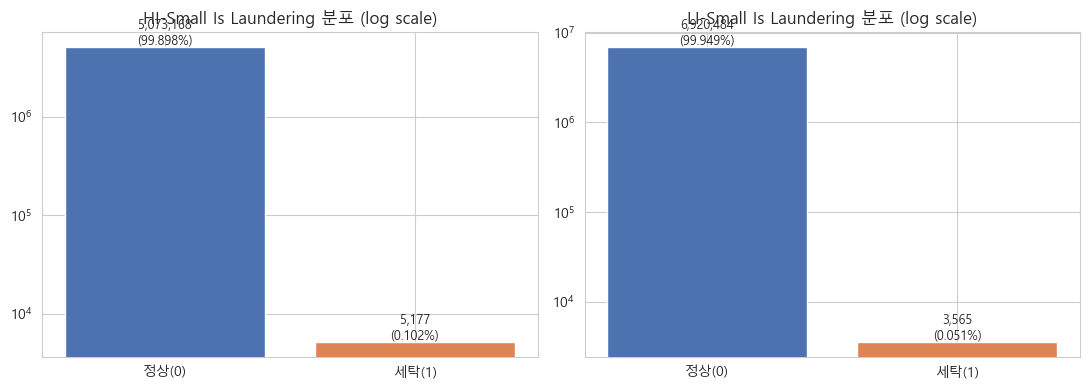

In [5]:
def target_stats(df, name):
    vc = df['IsLaundering'].value_counts().sort_index()
    n_norm, n_lau = int(vc[0]), int(vc[1])
    return {'정상': n_norm, '세탁': n_lau,
            '세탁 비율(%)': round(n_lau / len(df) * 100, 4),
            '불균형(정상:세탁)': f'{n_norm / n_lau:.0f} : 1'}

ts = pd.DataFrame([target_stats(hi, 'HI'), target_stats(li, 'LI')],
                  index=['HI-Small', 'LI-Small'])
summary['target'] = ts.to_dict('index')
display(ts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (df, name) in zip(axes, [(hi, 'HI-Small'), (li, 'LI-Small')]):
    vc = df['IsLaundering'].value_counts().sort_index()
    bars = ax.bar(['정상(0)', '세탁(1)'], vc.values, color=['#4C72B0', '#DD8452'])
    ax.set_yscale('log')
    ax.set_title(f'{name} Is Laundering 분포 (log scale)')
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n({v/len(df)*100:.3f}%)',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
savefig('fig01_target_distribution.png')
plt.show()

## 4. 시간 패턴

- 데이터 기간과 일별 거래량(전체 vs 세탁)
- 시간대(hour)별 분포: 세탁 거래가 특정 시간대에 몰리는지 — GNN에서 시간을 엣지 피처로 쓸지 판단하는 근거

In [6]:
for df, name in [(hi, 'HI-Small'), (li, 'LI-Small')]:
    print(f'{name}: {df["Timestamp"].min()} ~ {df["Timestamp"].max()} '
          f'({df["Timestamp"].dt.date.nunique()}일)')

HI-Small: 2022-09-01 00:00:00 ~ 2022-09-18 16:18:00 (18일)
LI-Small: 2022-09-01 00:00:00 ~ 2022-09-17 15:28:00 (17일)


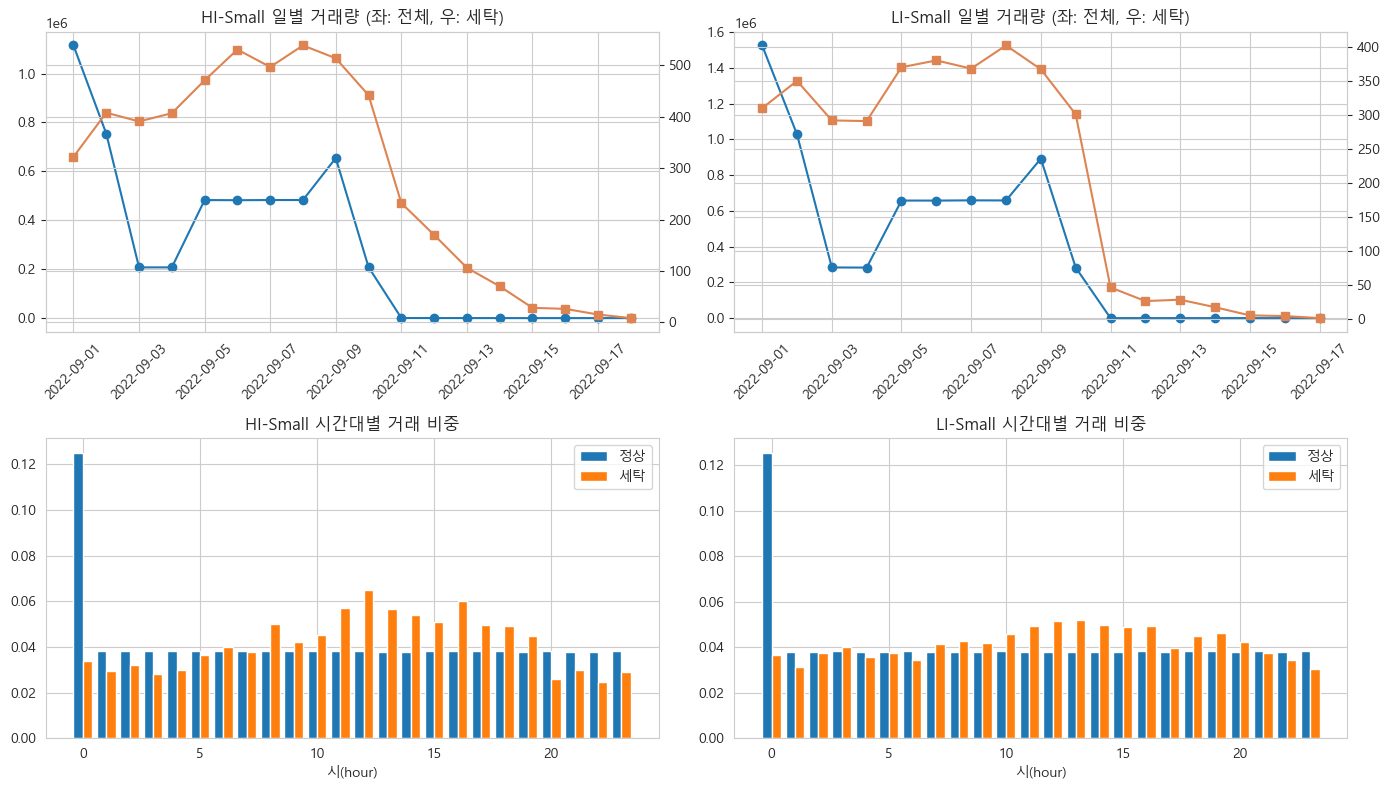

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col, (df, name) in enumerate([(hi, 'HI-Small'), (li, 'LI-Small')]):
    # 일별 거래량
    daily_all = df.groupby(df['Timestamp'].dt.date).size()
    daily_lau = df[df['IsLaundering'] == 1].groupby(df['Timestamp'].dt.date).size()
    ax = axes[0, col]
    ax.plot(daily_all.index, daily_all.values, marker='o', label='전체')
    ax2 = ax.twinx()
    ax2.plot(daily_lau.index, daily_lau.values, marker='s', color='#DD8452', label='세탁')
    ax.set_title(f'{name} 일별 거래량 (좌: 전체, 우: 세탁)')
    ax.tick_params(axis='x', rotation=45)

    # 시간대별 분포 (정규화)
    ax = axes[1, col]
    hours = df['Timestamp'].dt.hour
    h_norm = hours[df['IsLaundering'] == 0].value_counts(normalize=True).sort_index()
    h_lau = hours[df['IsLaundering'] == 1].value_counts(normalize=True).sort_index()
    x = np.arange(24)
    ax.bar(x - 0.2, h_norm.reindex(x, fill_value=0), width=0.4, label='정상')
    ax.bar(x + 0.2, h_lau.reindex(x, fill_value=0), width=0.4, label='세탁')
    ax.set_title(f'{name} 시간대별 거래 비중')
    ax.set_xlabel('시(hour)')
    ax.legend()
plt.tight_layout()
savefig('fig02_time_patterns.png')
plt.show()

## 5. 거래 금액(Amount) 분포

금액 스케일이 넓으므로 **로그 스케일**로 본다. 세탁 거래가 정상 거래와 다른 금액대를 쓰는지,
그리고 `Amount Paid` ≠ `Amount Received`(환전 수수료/환율 차이)인 비율도 확인한다.

In [8]:
amt_stats = pd.concat([
    hi.groupby('IsLaundering')['AmountPaid'].describe().assign(dataset='HI-Small'),
    li.groupby('IsLaundering')['AmountPaid'].describe().assign(dataset='LI-Small'),
]).set_index('dataset', append=True)
display(amt_stats)

# Paid != Received 비율 (통화 변환 거래)
for df, name in [(hi, 'HI-Small'), (li, 'LI-Small')]:
    diff = (df['AmountPaid'] != df['AmountReceived'])
    print(f'{name} Paid≠Received 거래: {diff.mean()*100:.2f}% '
          f'(세탁 중 {diff[df.IsLaundering==1].mean()*100:.2f}%)')

,,count,mean,std,min,25%,50%,75%,max
IsLaundering,dataset,,,,,,,,
0,HI-Small,5073168.0,4.477000e+06,8.688463e+08,0.000001,184.16,1410.99,12279.34,1.046302e+12
1,HI-Small,5177.0,3.613531e+07,1.527919e+09,0.003227,2634.97,8667.21,18832.27,8.485314e+10
0,LI-Small,6920484.0,4.676577e+06,1.544496e+09,0.000001,175.22,1398.16,12224.89,3.644854e+12
1,LI-Small,3565.0,3.626202e+06,6.220028e+07,0.001136,1461.77,4295.24,13971.04,2.473295e+09


HI-Small Paid≠Received 거래: 1.42% (세탁 중 0.00%)
LI-Small Paid≠Received 거래: 1.43% (세탁 중 0.00%)


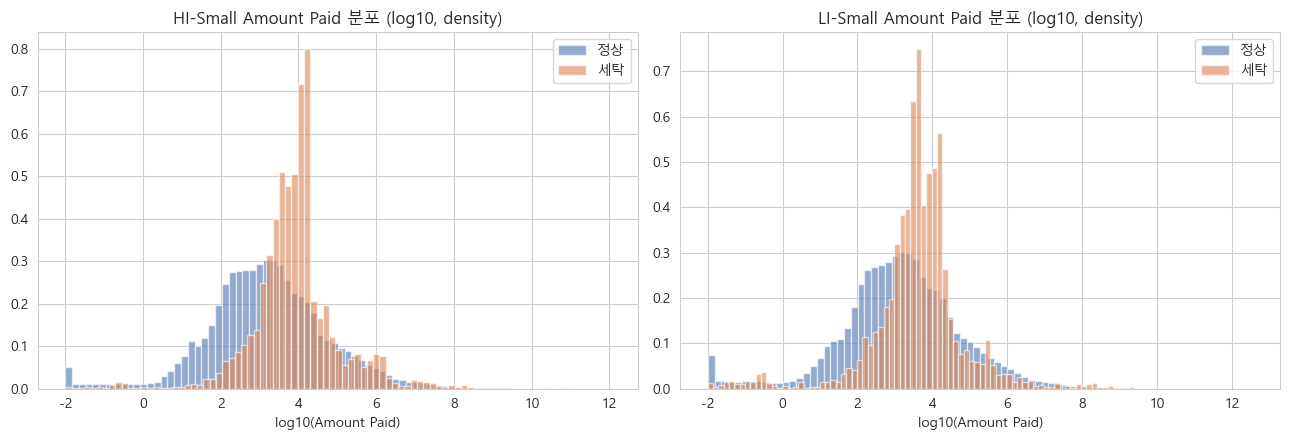

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (df, name) in zip(axes, [(hi, 'HI-Small'), (li, 'LI-Small')]):
    for lab, val, color in [(0, '정상', '#4C72B0'), (1, '세탁', '#DD8452')]:
        v = np.log10(df.loc[df['IsLaundering'] == lab, 'AmountPaid'].clip(lower=1e-2))
        ax.hist(v, bins=80, density=True, alpha=0.6, label=val, color=color)
    ax.set_title(f'{name} Amount Paid 분포 (log10, density)')
    ax.set_xlabel('log10(Amount Paid)')
    ax.legend()
plt.tight_layout()
savefig('fig03_amount_distribution.png')
plt.show()

## 6. 통화 / Payment Format 분포

- 세탁 거래가 특정 결제 수단(Payment Format)에 집중되는지 → **결제 수단별 세탁률** 확인
- 엣지 피처 설계(통화, 결제 수단의 원-핫/임베딩)에 직접 사용되는 정보

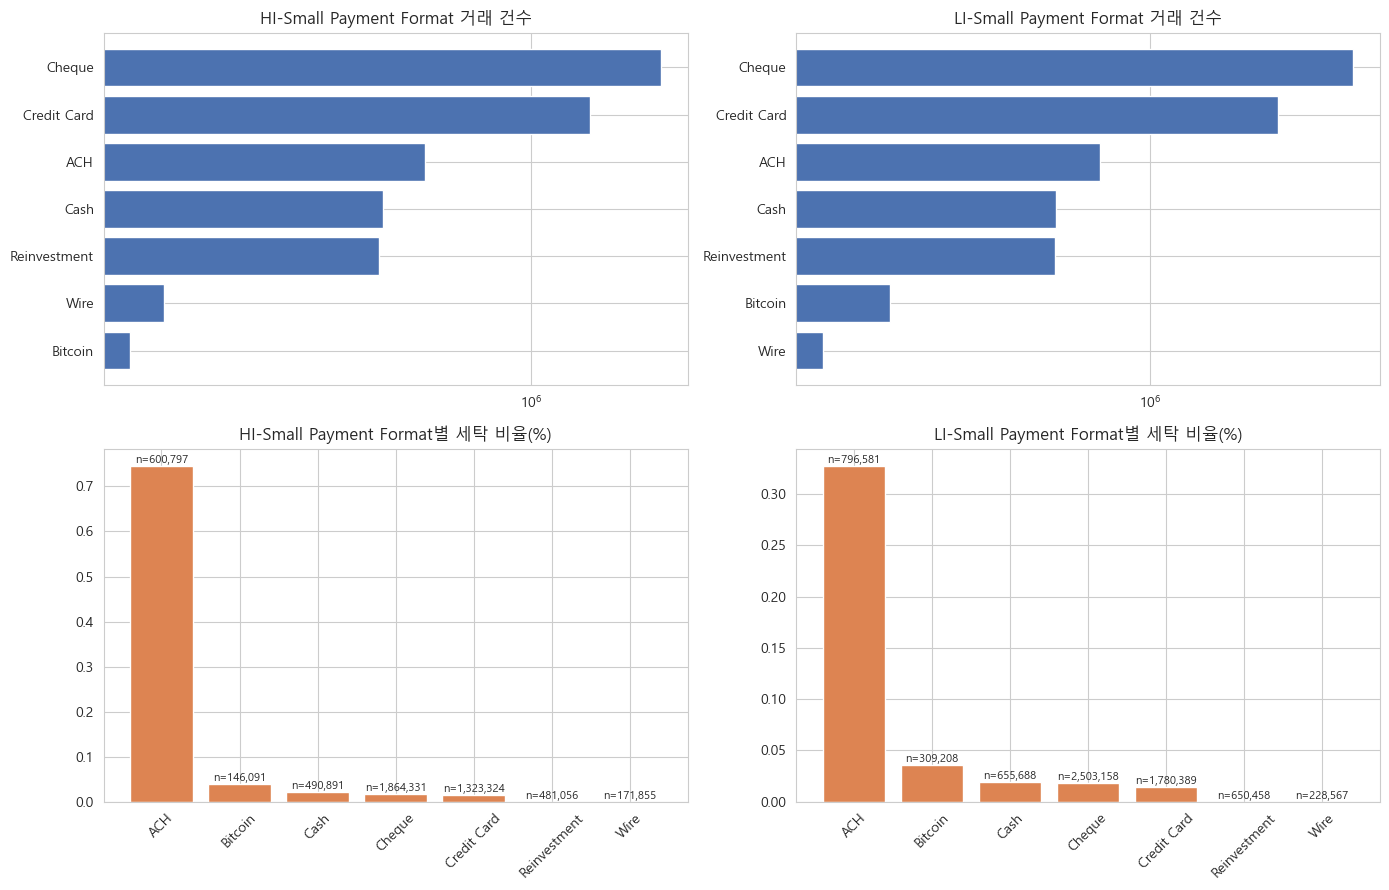

HI-Small 세탁률 최고 결제 수단: ACH
LI-Small 세탁률 최고 결제 수단: ACH


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, (df, name) in enumerate([(hi, 'HI-Small'), (li, 'LI-Small')]):
    # 결제 수단 분포
    ax = axes[0, col]
    pf = df['PaymentFormat'].value_counts()
    ax.barh(pf.index.astype(str)[::-1], pf.values[::-1], color='#4C72B0')
    ax.set_title(f'{name} Payment Format 거래 건수')
    ax.set_xscale('log')

    # 결제 수단별 세탁률
    ax = axes[1, col]
    rate = df.groupby('PaymentFormat', observed=True)['IsLaundering'].agg(['mean', 'count'])
    rate = rate.sort_values('mean', ascending=False)
    ax.bar(rate.index.astype(str), rate['mean'] * 100, color='#DD8452')
    ax.set_title(f'{name} Payment Format별 세탁 비율(%)')
    ax.tick_params(axis='x', rotation=45)
    for i, (m, c) in enumerate(zip(rate['mean'], rate['count'])):
        ax.text(i, m * 100, f'n={c:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
savefig('fig04_payment_format.png')
plt.show()

for df, name in [(hi, 'HI-Small'), (li, 'LI-Small')]:
    top_rate = df.groupby('PaymentFormat', observed=True)['IsLaundering'].mean().idxmax()
    summary.setdefault('fmt', {})[name] = str(top_rate)
    print(f'{name} 세탁률 최고 결제 수단: {top_rate}')

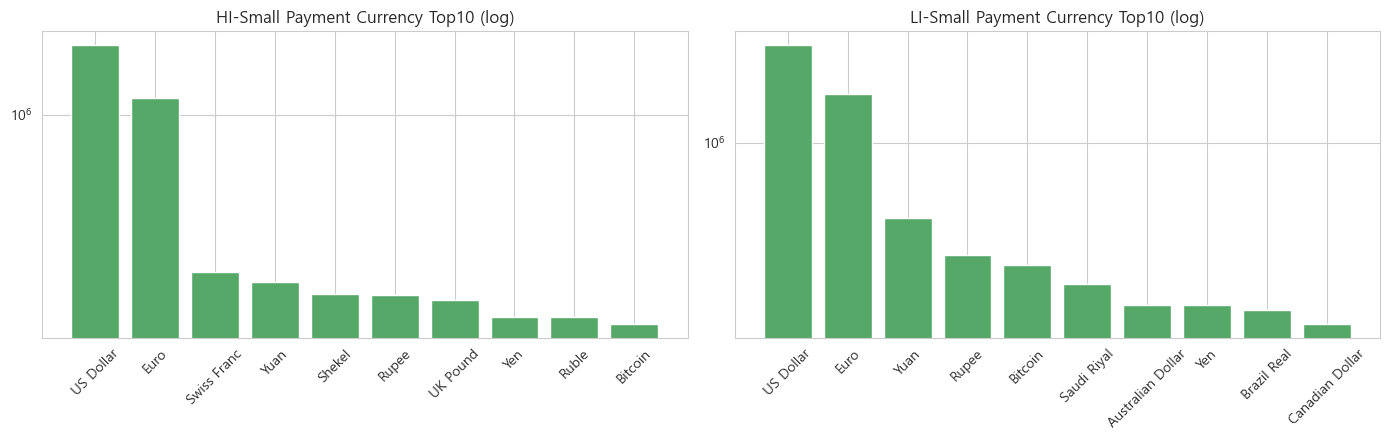

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (df, name) in zip(axes, [(hi, 'HI-Small'), (li, 'LI-Small')]):
    cur = df['PaymentCurrency'].value_counts().head(10)
    ax.bar(cur.index.astype(str), cur.values, color='#55A868')
    ax.set_yscale('log')
    ax.set_title(f'{name} Payment Currency Top10 (log)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig('fig05_currency_top10.png')
plt.show()

## 7. 자금흐름 유형 (셀프이체 / 동일은행 / 타행)

- **셀프이체**: From 계좌 = To 계좌 (재투자·계좌 간 이동 등)
- **동일은행**: 은행은 같고 계좌만 다름
- **타행**: 은행이 다름

유형별 세탁 비율 차이는 GNN에서 **엣지 타입(relation) 분리** 여부를 결정하는 근거가 된다.

,건수,비율(%),세탁 건수,세탁률(%)
HI-Small,,,,
셀프이체,591212,11.6418,11,0.0019
동일은행,100043,1.9700,92,0.0920
타행,4387090,86.3882,5074,0.1157


,건수,비율(%),세탁 건수,세탁률(%)
LI-Small,,,,
셀프이체,804477,11.6186,3,0.0004
동일은행,107525,1.5529,70,0.0651
타행,6012047,86.8285,3492,0.0581


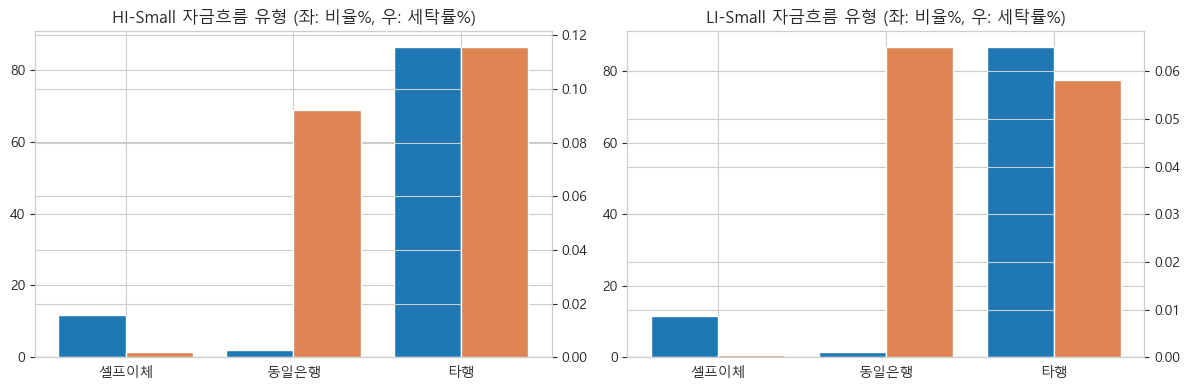

In [12]:
def flow_stats(df, name):
    self_tr = (df['FromBank'] == df['ToBank']) & (df['FromAccount'] == df['ToAccount'])
    same_bank = (df['FromBank'] == df['ToBank']) & ~self_tr
    cross = ~self_tr & ~same_bank
    out = pd.DataFrame({
        '건수': [self_tr.sum(), same_bank.sum(), cross.sum()],
        '비율(%)': [self_tr.mean() * 100, same_bank.mean() * 100, cross.mean() * 100],
        '세탁 건수': [df.loc[self_tr, 'IsLaundering'].sum(),
                    df.loc[same_bank, 'IsLaundering'].sum(),
                    df.loc[cross, 'IsLaundering'].sum()],
        '세탁률(%)': [df.loc[self_tr, 'IsLaundering'].mean() * 100,
                    df.loc[same_bank, 'IsLaundering'].mean() * 100,
                    df.loc[cross, 'IsLaundering'].mean() * 100],
    }, index=['셀프이체', '동일은행', '타행']).round(4)
    out.index.name = name
    return out

fs_hi, fs_li = flow_stats(hi, 'HI-Small'), flow_stats(li, 'LI-Small')
display(fs_hi)
display(fs_li)
summary['flow'] = {'HI': fs_hi['세탁률(%)'].to_dict(), 'LI': fs_li['세탁률(%)'].to_dict()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, fs, name in [(axes[0], fs_hi, 'HI-Small'), (axes[1], fs_li, 'LI-Small')]:
    x = np.arange(3)
    ax.bar(x - 0.2, fs['비율(%)'], width=0.4, label='전체 거래 비율')
    ax2 = ax.twinx()
    ax2.bar(x + 0.2, fs['세탁률(%)'], width=0.4, color='#DD8452', label='세탁률')
    ax.set_xticks(x, fs.index)
    ax.set_title(f'{name} 자금흐름 유형 (좌: 비율%, 우: 세탁률%)')
plt.tight_layout()
savefig('fig06_flow_type.png')
plt.show()

## 8. 그래프 구조 분석 (GNN 관점) ★

계좌를 **노드**, 거래를 **방향성 엣지**(From → To)로 하는 그래프를 구성한다.
수백만 노드 규모이므로 차수·연결요소 등 통계는 `numpy`/`scipy`로 계산하고,
`networkx`는 패턴 사례 서브그래프 시각화에만 사용한다.

### 8.1 그래프 구성 및 차수(degree) 계산

In [13]:
def build_graph(df):
    '''노드 = 은행ID/계좌번호, 엣지 = From -> To. 인덱스 배열 반환.'''
    src = (df['FromBank'] + '/' + df['FromAccount']).to_numpy()
    dst = (df['ToBank'] + '/' + df['ToAccount']).to_numpy()
    nodes, inv = np.unique(np.concatenate([src, dst]), return_inverse=True)
    s, d = inv[:len(src)], inv[len(src):]
    return {'nodes': nodes, 's': s, 'd': d,
            'lau': df['IsLaundering'].to_numpy() == 1}

G_hi, G_li = build_graph(hi), build_graph(li)

for G, name in [(G_hi, 'HI-Small'), (G_li, 'LI-Small')]:
    n = len(G['nodes'])
    G['in_deg'] = np.bincount(G['d'], minlength=n)
    G['out_deg'] = np.bincount(G['s'], minlength=n)
    print(f'{name}: 노드 {n:,}개, 엣지(거래) {len(G["s"]):,}개, '
          f'평균 차수 {len(G["s"]) / n:.2f}')
    summary.setdefault('graph', {})[name] = {
        'nodes': int(n), 'edges': int(len(G['s']))}

HI-Small: 노드 515,088개, 엣지(거래) 5,078,345개, 평균 차수 9.86
LI-Small: 노드 705,907개, 엣지(거래) 6,924,049개, 평균 차수 9.81


### 8.2 차수 분포 (로그-로그)

자금세탁 네트워크는 허브(계좌 집중) 구조를 가지는지 — **power-law 성향** 여부를 로그-로그 차수 분포로 확인한다.
long-tail이 심하면 degree 기반 피처/정규화가 중요해진다.

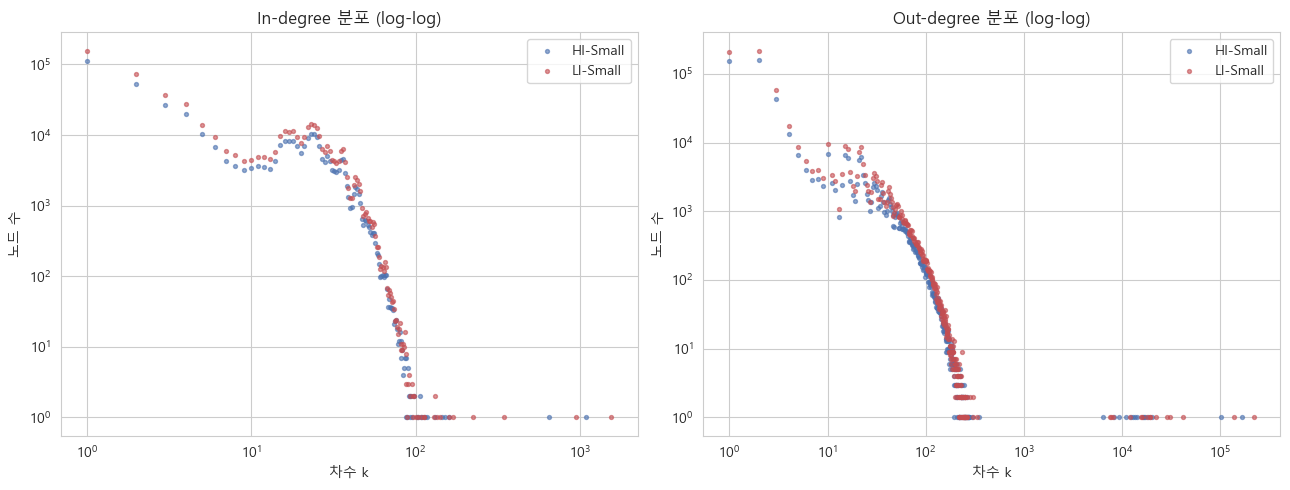

HI-Small: 최대 in-degree 1,084, 최대 out-degree 168,672, 차수 1~2 노드 비율 31.1%
LI-Small: 최대 in-degree 1,553, 최대 out-degree 222,037, 차수 1~2 노드 비율 31.4%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kind, title in [(axes[0], 'in_deg', 'In-degree'), (axes[1], 'out_deg', 'Out-degree')]:
    for G, name, color in [(G_hi, 'HI-Small', '#4C72B0'), (G_li, 'LI-Small', '#C44E52')]:
        cnt = np.bincount(G[kind])
        k = np.nonzero(cnt)[0]
        ax.scatter(k, cnt[k], s=8, alpha=0.6, label=name, color=color)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('차수 k'); ax.set_ylabel('노드 수')
    ax.set_title(f'{title} 분포 (log-log)')
    ax.legend()
plt.tight_layout()
savefig('fig07_degree_distribution.png')
plt.show()

for G, name in [(G_hi, 'HI-Small'), (G_li, 'LI-Small')]:
    tot = G['in_deg'] + G['out_deg']
    print(f'{name}: 최대 in-degree {G["in_deg"].max():,}, 최대 out-degree {G["out_deg"].max():,}, '
          f'차수 1~2 노드 비율 {(tot <= 2).mean() * 100:.1f}%')

### 8.3 세탁 관련 계좌 vs 정상 계좌 — 차수 비교

세탁 거래에 한 번이라도 연루된 계좌(**세탁 노드**)와 그 외 계좌의 차수 분포를 비교한다.
세탁 노드가 구조적으로 구분되는 차수 특성을 보이면, degree가 유효한 노드 피처가 된다.

,세탁 노드,정상 노드
count,6357.000000,508731.000000
mean,102.750000,18.680000
std,2576.660000,25.650000
min,1.000000,1.000000
25%,8.000000,2.000000
50%,22.000000,6.000000
75%,41.000000,27.000000
max,169756.000000,394.000000


,세탁 노드,정상 노드
count,5304.000000,700603.000000
mean,147.350000,18.650000
std,3773.400000,25.630000
min,1.000000,1.000000
25%,8.000000,2.000000
50%,22.000000,6.000000
75%,41.000000,27.000000
max,223590.000000,368.000000


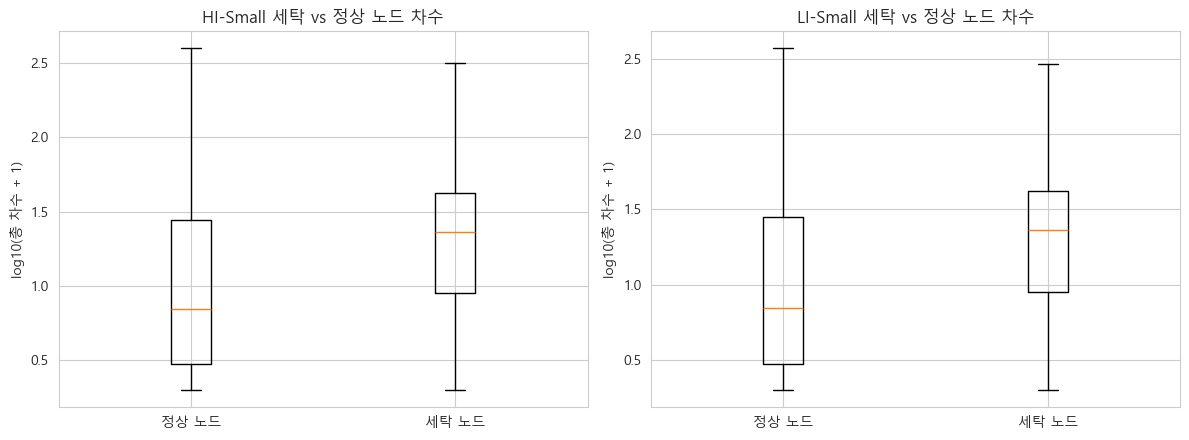

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
comp_rows = []
for ax, (G, name) in zip(axes, [(G_hi, 'HI-Small'), (G_li, 'LI-Small')]):
    lau_nodes = np.unique(np.concatenate([G['s'][G['lau']], G['d'][G['lau']]]))
    G['lau_nodes'] = lau_nodes
    tot = G['in_deg'] + G['out_deg']
    lau_mask = np.zeros(len(tot), dtype=bool); lau_mask[lau_nodes] = True
    comp = pd.DataFrame({
        '세탁 노드': pd.Series(tot[lau_mask]).describe(),
        '정상 노드': pd.Series(tot[~lau_mask]).describe(),
    }).round(2)
    display(comp.style.set_caption(f'{name} 총 차수 비교 (세탁 노드 {lau_mask.sum():,}개, '
                                   f'전체의 {lau_mask.mean()*100:.3f}%)'))
    comp_rows.append((name, int(lau_mask.sum()), float(tot[lau_mask].mean()), float(tot[~lau_mask].mean())))
    data = [np.log10(tot[~lau_mask] + 1), np.log10(tot[lau_mask] + 1)]
    ax.boxplot(data, tick_labels=['정상 노드', '세탁 노드'], showfliers=False)
    ax.set_ylabel('log10(총 차수 + 1)')
    ax.set_title(f'{name} 세탁 vs 정상 노드 차수')
summary['lau_nodes'] = comp_rows
plt.tight_layout()
savefig('fig08_laundering_node_degree.png')
plt.show()

### 8.4 Fan-in / Fan-out 패턴 사례 — 서브그래프 시각화

`Patterns.txt`에서 패턴 유형별 실제 사례를 뽑아 `networkx` 서브그래프로 그린다.
(FAN-OUT: 한 계좌가 다수로 분산, FAN-IN: 다수가 한 계좌로 집중, CYCLE: 순환, SCATTER-GATHER: 분산 후 재집중)

먼저 Patterns.txt 파서를 정의한다(9절에서도 재사용).

In [16]:
def parse_patterns(path):
    '''Patterns.txt -> [{'type': 패턴유형, 'rows': [거래행,...]}, ...]'''
    patterns, cur = [], None
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('BEGIN LAUNDERING ATTEMPT'):
                m = re.search(r'ATTEMPT - ([A-Z-]+)', line)
                cur = {'type': m.group(1), 'rows': []}
            elif line.startswith('END LAUNDERING ATTEMPT'):
                patterns.append(cur)
                cur = None
            elif cur is not None and line:
                cur['rows'].append(line.split(','))
    return patterns

hi_patterns = parse_patterns(os.path.join(DATA_DIR, 'HI-Small_Patterns.txt'))
li_patterns = parse_patterns(os.path.join(DATA_DIR, 'LI-Small_Patterns.txt'))
print(f'HI-Small 패턴 {len(hi_patterns)}건, LI-Small 패턴 {len(li_patterns)}건')

def pattern_to_graph(pat):
    g = nx.DiGraph()
    for r in pat['rows']:
        g.add_edge(f'{r[1]}/{r[2]}', f'{r[3]}/{r[4]}')
    return g

HI-Small 패턴 370건, LI-Small 패턴 117건


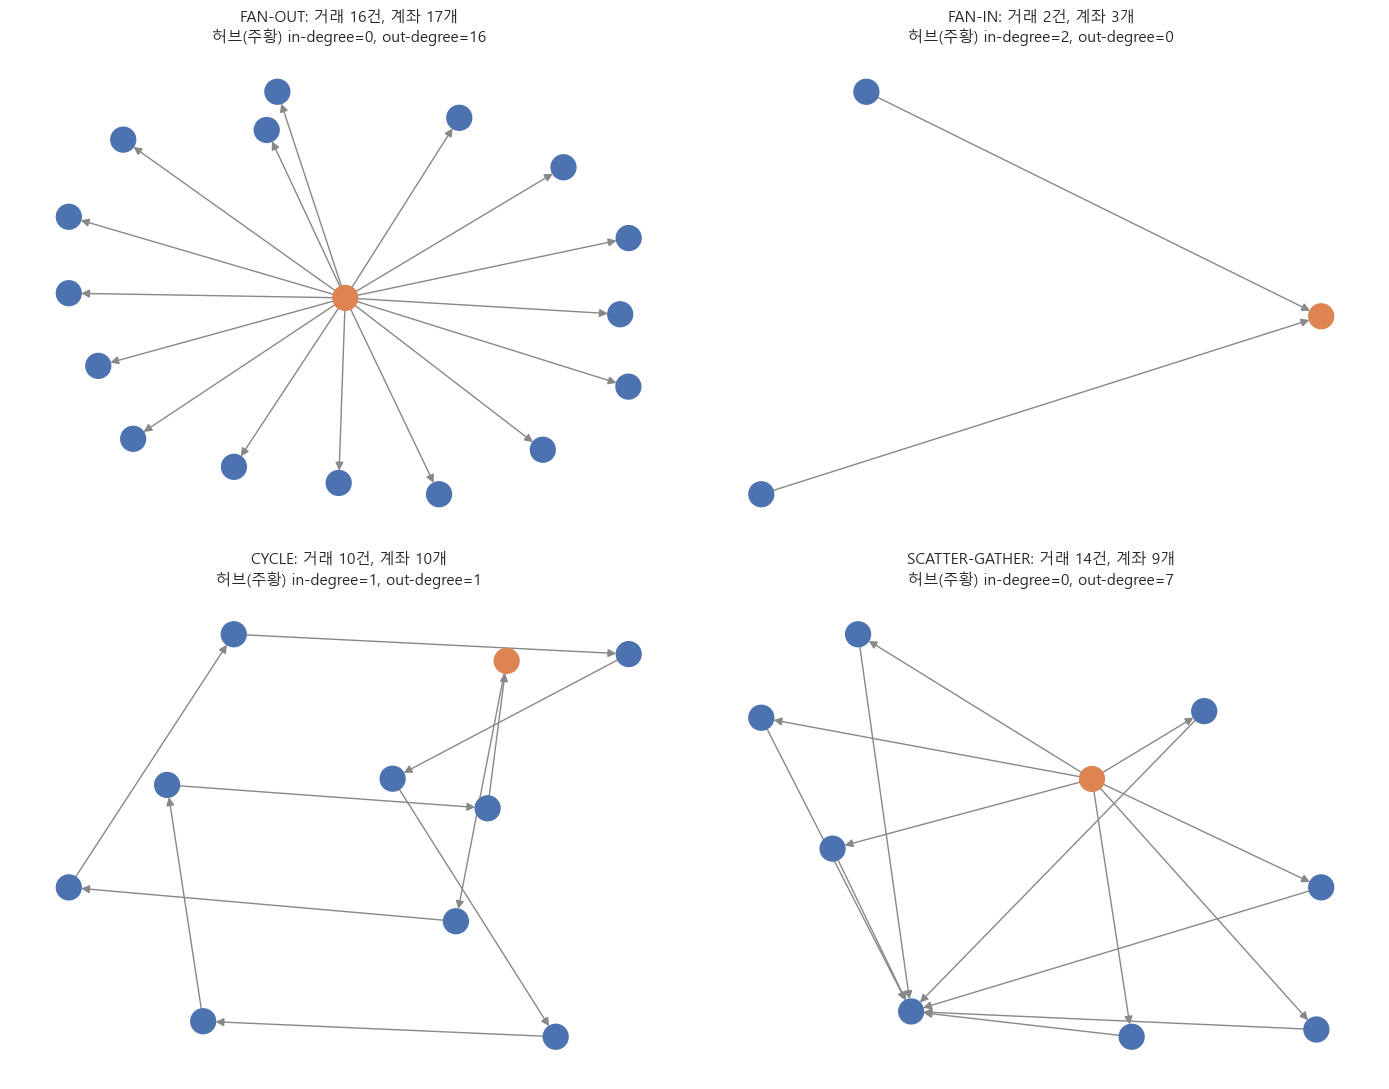

,n_edges,max_out,max_in
type,,,
SCATTER-GATHER,14.180000,7.090000,7.090000
GATHER-SCATTER,13.750000,6.980000,6.980000
STACK,10.590000,1.000000,1.000000
FAN-IN,7.520000,1.000000,7.520000
FAN-OUT,7.330000,7.310000,1.000000
BIPARTITE,6.030000,1.000000,1.000000
CYCLE,5.610000,1.000000,1.000000
RANDOM,4.790000,1.000000,1.000000


In [17]:
# HI-Small에서 유형별 대표 사례 1건씩 (엣지 30개 이하인 것 중 첫 번째)
examples = {}
for ptype in ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER']:
    for p in hi_patterns:
        if p['type'] == ptype and len(p['rows']) <= 30:
            examples[ptype] = p
            break

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (ptype, pat) in zip(axes.ravel(), examples.items()):
    g = pattern_to_graph(pat)
    pos = nx.spring_layout(g, seed=42, k=1.2)
    degs = dict(g.degree())
    hub = max(degs, key=degs.get)
    colors = ['#DD8452' if n == hub else '#4C72B0' for n in g.nodes()]
    nx.draw(g, pos, ax=ax, node_color=colors, node_size=320,
            arrows=True, arrowsize=12, width=1.0, edge_color='#888888')
    in_d, out_d = g.in_degree(hub), g.out_degree(hub)
    ax.set_title(f'{ptype}: 거래 {g.number_of_edges()}건, 계좌 {g.number_of_nodes()}개\n'
                 f'허브(주황) in-degree={in_d}, out-degree={out_d}', fontsize=11)
plt.tight_layout()
savefig('fig09_pattern_subgraphs.png')
plt.show()

# 패턴 유형별 허브 차수 특성 (전체 패턴 대상)
rows = []
for p in hi_patterns + li_patterns:
    g = pattern_to_graph(p)
    rows.append({'type': p['type'], 'n_edges': g.number_of_edges(),
                 'max_out': max(dict(g.out_degree()).values()),
                 'max_in': max(dict(g.in_degree()).values())})
pat_deg = pd.DataFrame(rows)
display(pat_deg.groupby('type')[['n_edges', 'max_out', 'max_in']].mean().round(2)
        .sort_values('n_edges', ascending=False)
        .style.set_caption('패턴 유형별 평균 거래 수 / 최대 in·out 차수 (HI+LI 합산)'))

### 8.5 연결요소(connected component) 분석

세탁 거래가 **정상 거래 그래프와 분리된 별도 컴포넌트**에 있는지, 거대 컴포넌트 안에 섞여 있는지에 따라
GNN의 inductive/transductive 설정과 라벨 전파 가능성이 달라진다.

[HI-Small] 연결요소 114,139개 | 최대 크기 372,089 (전체 노드의 72.2%)
  세탁 노드가 속한 컴포넌트: 8개, 평균 크기 46513.8, 중앙값 3, 최대 372,089


[LI-Small] 연결요소 160,033개 | 최대 크기 504,391 (전체 노드의 71.5%)
  세탁 노드가 속한 컴포넌트: 10개, 평균 크기 50441.8, 중앙값 3, 최대 504,391


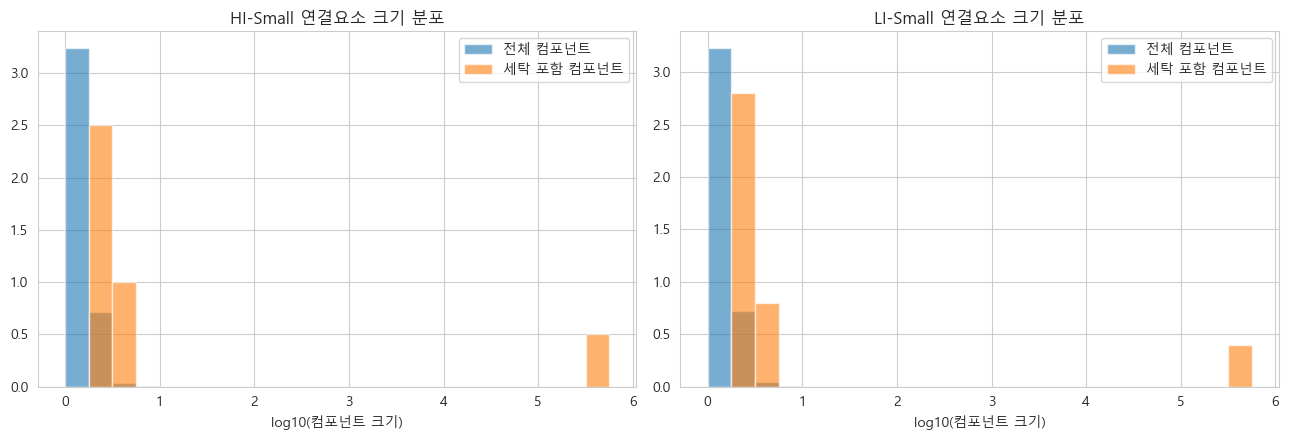

In [18]:
for G, name in [(G_hi, 'HI-Small'), (G_li, 'LI-Small')]:
    n = len(G['nodes'])
    adj = csr_matrix((np.ones(len(G['s'])), (G['s'], G['d'])), shape=(n, n))
    n_comp, labels = connected_components(adj, directed=False)
    sizes = np.bincount(labels)
    lau_comp = np.unique(labels[G['lau_nodes']])
    lau_sizes = sizes[lau_comp]
    print(f'[{name}] 연결요소 {n_comp:,}개 | 최대 크기 {sizes.max():,} '
          f'(전체 노드의 {sizes.max()/n*100:.1f}%)')
    print(f'  세탁 노드가 속한 컴포넌트: {len(lau_comp):,}개, '
          f'평균 크기 {lau_sizes.mean():.1f}, 중앙값 {np.median(lau_sizes):.0f}, '
          f'최대 {lau_sizes.max():,}')
    summary['graph'][name].update({'n_components': int(n_comp),
                                   'largest_comp': int(sizes.max()),
                                   'lau_components': int(len(lau_comp))})
    G['comp_sizes'], G['lau_comp_sizes'] = sizes, lau_sizes

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (G, name) in zip(axes, [(G_hi, 'HI-Small'), (G_li, 'LI-Small')]):
    bins = np.arange(0, np.log10(G['comp_sizes'].max()) + 0.25, 0.25)
    ax.hist(np.log10(G['comp_sizes']), bins=bins, alpha=0.6, label='전체 컴포넌트', density=True)
    ax.hist(np.log10(G['lau_comp_sizes']), bins=bins, alpha=0.6, label='세탁 포함 컴포넌트', density=True)
    ax.set_xlabel('log10(컴포넌트 크기)')
    ax.set_title(f'{name} 연결요소 크기 분포')
    ax.legend()
plt.tight_layout()
savefig('fig10_connected_components.png')
plt.show()

### 8.6 GNN 노드 피처 후보

계좌 단위로 계산 가능한 구조·집계 피처를 정리하고, 세탁 노드와 정상 노드 간 분포 차이를 확인한다.

| 후보 피처 | 정의 | 기대 근거 |
|---|---|---|
| in-degree / out-degree | 입금/출금 거래 상대 수 | Fan-in/Fan-out 패턴 직접 반영 |
| 총 차수 | in+out | 허브 여부 |
| 거래 건수 | 총 거래 수 | 활동량 |
| 총 송금액 / 총 수금액 | Amount Paid/Received 합 | 자금 규모 |
| 순자금흐름 | 수금-송금 | 자금 통과(≈0) vs 정체 |
| 셀프이체 횟수 | From=To 거래 수 | 재투자 위장 여부 |
| 세탁 연루 여부 | (타겟) 세탁 거래 연루 | 노드 분류 라벨 후보 |

In [19]:
def node_features(G, df, name):
    n = len(G['nodes'])
    tot_sent = np.bincount(G['s'], weights=df['AmountPaid'].to_numpy(), minlength=n)
    tot_recv = np.bincount(G['d'], weights=df['AmountReceived'].to_numpy(), minlength=n)
    self_loop = np.bincount(G['s'][G['s'] == G['d']], minlength=n)
    feat = pd.DataFrame({
        'in_degree': G['in_deg'], 'out_degree': G['out_deg'],
        'total_sent': tot_sent, 'total_recv': tot_recv,
        'net_flow': tot_recv - tot_sent, 'self_loops': self_loop,
    })
    feat['is_laundering_node'] = False
    feat.loc[G['lau_nodes'], 'is_laundering_node'] = True
    return feat

nf_hi = node_features(G_hi, hi, 'HI-Small')
nf_li = node_features(G_li, li, 'LI-Small')

cmp_feat = pd.concat([
    nf_hi.groupby('is_laundering_node')[['in_degree', 'out_degree', 'total_sent',
                                         'total_recv', 'net_flow', 'self_loops']]
        .mean().round(2).assign(dataset='HI-Small'),
    nf_li.groupby('is_laundering_node')[['in_degree', 'out_degree', 'total_sent',
                                         'total_recv', 'net_flow', 'self_loops']]
        .mean().round(2).assign(dataset='LI-Small'),
]).set_index('dataset', append=True)
display(cmp_feat.style.set_caption('노드 피처 평균 — 세탁 노드(True) vs 정상 노드(False)'))

# 세탁 노드 상위 사례
cols = ['in_degree', 'out_degree', 'total_sent', 'total_recv', 'net_flow', 'self_loops']
top_lau = nf_hi[nf_hi['is_laundering_node']].nlargest(5, 'out_degree')[cols]
display(top_lau.style.set_caption('HI-Small 세탁 노드 중 out-degree 상위 5개 계좌'))
summary['node_feat'] = cmp_feat.round(2).to_dict()

,,in_degree,out_degree,total_sent,total_recv,net_flow,self_loops
is_laundering_node,dataset,,,,,,
False,HI-Small,9.780000,8.900000,42284317.800000,58929096.790000,16644778.990000,1.140000
True,HI-Small,16.070000,86.680000,218389583.100000,68233247.300000,-150156335.790000,1.850000
False,LI-Small,9.760000,8.890000,41981573.570000,61311054.030000,19329480.460000,1.140000
True,LI-Small,16.060000,131.290000,558952830.740000,157133987.170000,-401818843.570000,1.560000


,in_degree,out_degree,total_sent,total_recv,net_flow,self_loops
515073,1084,168672,52762291209.751404,479594.790000,-52761811614.961403,0
515074,653,103018,26069375477.370369,251001.270000,-26069124476.100368,0
515084,150,20497,7532109611.709904,44445.620000,-7532065166.089904,0
515075,108,18663,24657357382.930061,253933.880000,-24657103449.050060,0
515077,117,17264,373933699163.911743,10570889.950000,-373923128273.961731,0


## 9. Patterns.txt 파싱 — 패턴 유형 통계

AMLSim이 주입한 세탁 패턴의 유형별 건수, 패턴당 거래 수, 패턴 지속 기간을 비교한다.

dataset,HI-Small,LI-Small
type,,
BIPARTITE,49,16
CYCLE,54,12
FAN-IN,40,12
FAN-OUT,48,19
GATHER-SCATTER,51,12
RANDOM,41,15
SCATTER-GATHER,44,13
STACK,43,18


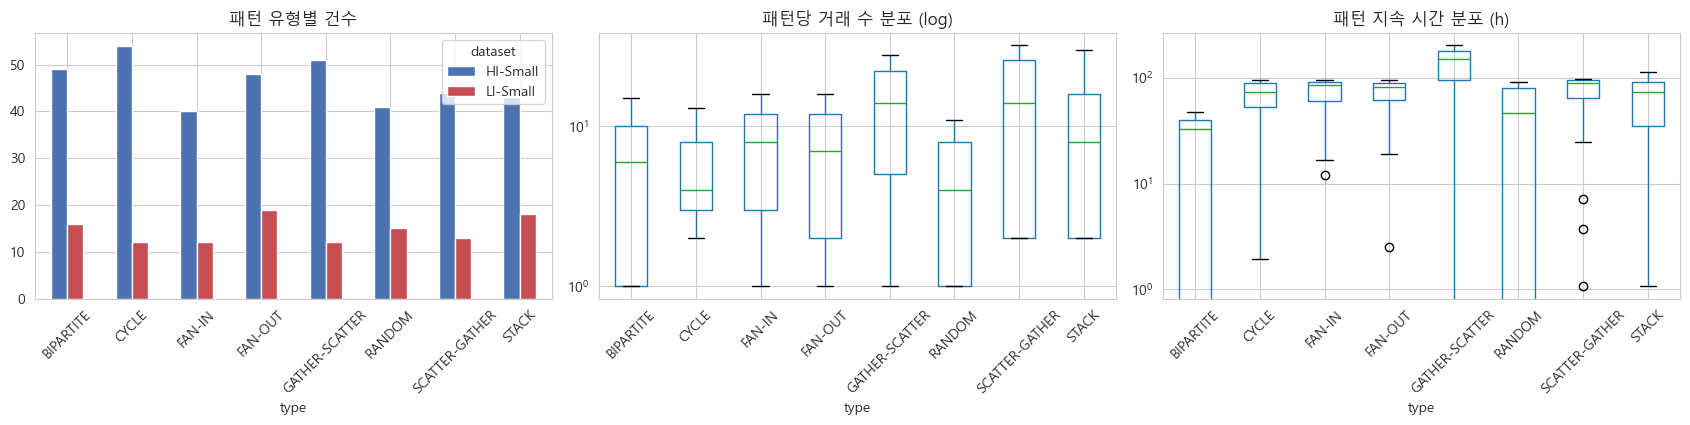

In [20]:
def pattern_stats(patterns, name):
    rows = []
    for p in patterns:
        ts = pd.to_datetime([r[0] for r in p['rows']], format='%Y/%m/%d %H:%M')
        rows.append({'type': p['type'], 'n_txns': len(p['rows']),
                     'duration_h': (ts.max() - ts.min()).total_seconds() / 3600})
    df = pd.DataFrame(rows)
    df['dataset'] = name
    return df

ps = pd.concat([pattern_stats(hi_patterns, 'HI-Small'),
                pattern_stats(li_patterns, 'LI-Small')])

# 유형별 건수
cnt = ps.groupby(['dataset', 'type']).size().unstack(0).fillna(0).astype(int)
display(cnt.style.set_caption('패턴 유형별 건수'))
summary['patterns'] = cnt.to_dict()

# 패턴당 거래 수 / 지속 기간
agg = ps.groupby(['dataset', 'type']).agg(
    평균거래수=('n_txns', 'mean'), 최대거래수=('n_txns', 'max'),
    중앙지속시간_h=('duration_h', 'median')).round(1)
display(agg.style.set_caption('패턴 유형별 거래 수 / 지속 시간(시간)'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
cnt.plot.bar(ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title('패턴 유형별 건수'); axes[0].tick_params(axis='x', rotation=45)
ps.boxplot(column='n_txns', by='type', ax=axes[1])
axes[1].set_title('패턴당 거래 수 분포'); axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45); plt.sca(axes[1]); plt.title('패턴당 거래 수 분포 (log)')
ps.boxplot(column='duration_h', by='type', ax=axes[2])
axes[2].set_title('패턴 지속 시간 분포 (h)'); axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=45)
fig.suptitle('')
plt.tight_layout()
savefig('fig11_pattern_stats.png')
plt.show()

## 10. 요약 — GNN 모델링 시사점

아래 코드 셀의 수치를 근거로 한 시사점:

1. **극심한 클래스 불균형**: 세탁 거래는 전체의 0.1% 미만 수준 → 엣지 분류 시 class weight,
   focal loss, 또는 세탁 노드 중심 서브그래프 샘플링이 필수적.
2. **degree long-tail (power-law)**: 소수 허브 계좌가 존재 → GraphSAGE류 이웃 샘플링 기반
   모델이 full-batch GCN보다 적합. 차수 피처는 로그 변환 권장.
3. **Fan-in/Fan-out이 핵심 패턴**: 방향성과 차수 정보가 중요 → 물방향 처리하거나
   in/out 엣지를 relation으로 구분하는 R-GCN / 방향성 집계 고려.
4. **세탁 노드의 구조적 특이성**: 세탁 노드는 평균 차수·거래금액·셀프이체 비율에서
   정상 노드와 차이를 보임 → 8.6의 집계 피처가 노드 분류(GNN 보조 태스크)에 유효.
5. **결제 수단 편중**: 세탁이 특정 Payment Format에 집중 → 엣지 피처에 Payment Format
   임베딩 포함 가치 있음.
6. **연결요소 구조**: 세탁 거래가 속한 컴포넌트 규모 분포를 확인해,
   컴포넌트 단위 train/valid 분할(누수 방지) 가능 여부의 근거로 활용.
7. **HI vs LI 차이**: 거래 규모·통화 분포가 다르므로 데이터셋별 학습 또는
   도메인 정규화 검토 필요.

In [21]:
print('=' * 60)
print('핵심 수치 요약')
print('=' * 60)
t = summary['target']
for name in ['HI-Small', 'LI-Small']:
    print(f"[{name}] 거래 {summary['graph'][name]['edges']:,}건, 계좌 {summary['graph'][name]['nodes']:,}개")
    print(f"  세탁 거래: {t[name]['세탁']:,}건 ({t[name]['세탁 비율(%)']}%), 불균형 {t[name]['불균형(정상:세탁)']}")
    g = summary['graph'][name]
    print(f"  연결요소 {g['n_components']:,}개, 최대 {g['largest_comp']:,}노드, 세탁 포함 {g['lau_components']:,}개")
ln = summary['lau_nodes']
for name, cnt_n, lau_d, norm_d in ln:
    print(f'[{name}] 세탁 노드 {cnt_n:,}개 | 평균 차수: 세탁 {lau_d:.1f} vs 정상 {norm_d:.1f}')
print('\n패턴 유형별 건수:')
print(pd.DataFrame(summary['patterns']).to_string())

핵심 수치 요약
[HI-Small] 거래 5,078,345건, 계좌 515,088개
  세탁 거래: 5,177건 (0.1019%), 불균형 980 : 1
  연결요소 114,139개, 최대 372,089노드, 세탁 포함 8개
[LI-Small] 거래 6,924,049건, 계좌 705,907개
  세탁 거래: 3,565건 (0.0515%), 불균형 1941 : 1
  연결요소 160,033개, 최대 504,391노드, 세탁 포함 10개
[HI-Small] 세탁 노드 6,357개 | 평균 차수: 세탁 102.8 vs 정상 18.7
[LI-Small] 세탁 노드 5,304개 | 평균 차수: 세탁 147.3 vs 정상 18.7

패턴 유형별 건수:
                HI-Small  LI-Small
BIPARTITE             49        16
CYCLE                 54        12
FAN-IN                40        12
FAN-OUT               48        19
GATHER-SCATTER        51        12
RANDOM                41        15
SCATTER-GATHER        44        13
STACK                 43        18
